# 1. Setup and Data Generation
We need a realistic dataset with:

- Numerical features (age, salary)

- Categorical features (color – nominal, size – ordinal)

- A binary target dependent on some conditions

- Missing values (~10% per column)

**Why generate synthetic data?**</br>
To have full control over the data properties and to clearly see the effect of each preprocessing step.

We'll use `numpy` and `pandas` to create the data. We'll also import the necessary scikit‑learn modules as we go.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [77]:
def create_sample_data(n_samples=500):
    np.random.seed(42)
    half = n_samples // 2

    age0 = np.random.randint(18, 40, half)
    salary0 = np.random.normal(30000, 10000, half)
    color0 = np.random.choice(['red','green'], half, p=[0.5,0.5])
    size0 = np.random.choice(['S','M','L'], half, p=[0.3,0.4,0.3])

    age1 = np.random.randint(40, 70, n_samples - half)
    salary1 = np.random.normal(60000, 15000, n_samples - half)
    color1 = np.random.choice(['blue','red','green'], n_samples - half, p=[0.6,0.2,0.2])
    size1 = np.random.choice(['S','M','L'], n_samples - half, p=[0.3,0.4,0.3])

    age = np.concatenate([age0, age1])
    salary = np.concatenate([salary0, salary1])
    color = np.concatenate([color0, color1])
    size = np.concatenate([size0, size1])
    target = np.concatenate([np.zeros(half), np.ones(n_samples - half)])

    idx = np.random.permutation(n_samples)
    age = age[idx]
    salary = salary[idx]
    color = color[idx]
    size = size[idx]
    target = target[idx]

    df = pd.DataFrame({
        'age': age,
        'salary': salary,
        'color': color,
        'size': size,
        'target': target
    })
    for col in ['age', 'salary', 'color', 'size']:
        mask = np.random.random(n_samples) < 0.2
        df.loc[mask, col] = np.nan
    return df

In [78]:
df = create_sample_data(2500)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     1977 non-null   float64
 1   salary  1995 non-null   float64
 2   color   2031 non-null   object 
 3   size    2014 non-null   object 
 4   target  2500 non-null   float64
dtypes: float64(3), object(2)
memory usage: 97.8+ KB


# 2. Handling Missing Data
**Theory recap:**</br>
Missing values are common. Strategies: drop rows, drop columns, or impute.
Imputation statistics (mean, median, mode) must be computed on the training set only to avoid data leakage.

Here we:

- Detect missing values

- Visualise them

- Apply row/column dropping (demonstration)

- Impute numerical columns with mean, categorical with mode

Missing values info:

age       523
salary    505
color     469
size      486
target      0
dtype: int64


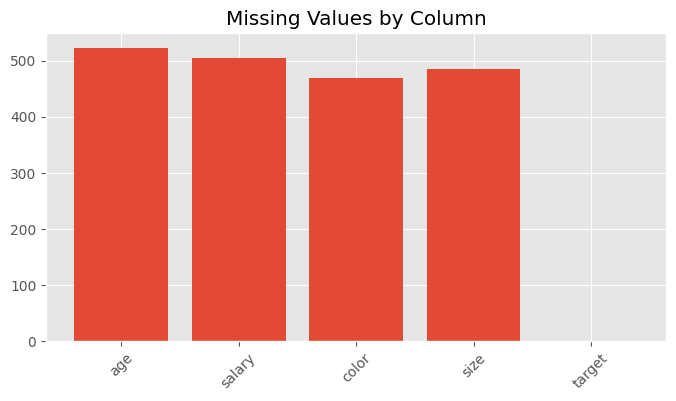

In [79]:
missing_counts = df.isna().sum()
print(f"Missing values info:\n\n{missing_counts}")

plt.style.use('ggplot')
plt.figure(figsize=(8, 4))
plt.bar(df.columns, missing_counts)
plt.title('Missing Values by Column')
plt.xticks(rotation=45)
plt.show()

In [80]:
df_drop_rows = df.dropna()
print(f"Df size after rows dropping: {df_drop_rows.shape}")

df_drop_column = df.drop(columns=['salary'])
print(f"Df size after column dropping: {df_drop_column.shape}")

Df size after rows dropping: (1057, 5)
Df size after column dropping: (2500, 4)


In [81]:
num_cols = ['age', 'salary']
cat_cols = ['color', 'size']

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')
df_impute = df.copy()

df_impute[num_cols] = num_imputer.fit_transform(df_impute[num_cols])
df_impute[cat_cols] = cat_imputer.fit_transform(df_impute[cat_cols])

print(f"After imputation, missing values left:\n{df_impute.isna().sum()}")

After imputation, missing values left:
age       0
salary    0
color     0
size      0
target    0
dtype: int64


In [82]:
def evaluate_imputation(df, desc):
    X = df.drop('target', axis=1)
    y = df['target']
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
    scaler = StandardScaler().fit(X_train[num_cols])
    X_train[num_cols], X_test[num_cols] = scaler.transform(X_train[num_cols]),\
    scaler.transform(X_test[num_cols])

    lr = LogisticRegression().fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    imputer_score = accuracy_score(y_test, lr_pred)
    print(f"Accuracy for {desc} imputer: {imputer_score:.2f}")

df_imputed = df.copy()
df_imputed[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df_imputed[cat_cols])
for imp_type in ['median', 'mean', 'most_frequent']:
    imputer = SimpleImputer(strategy=imp_type)
    df_imputed[num_cols] = imputer.fit_transform(df_imputed[num_cols])
    evaluate_imputation(df_imputed, imp_type)

Accuracy for median imputer: 0.97
Accuracy for mean imputer: 0.96
Accuracy for most_frequent imputer: 0.97


Usually, the difference is not visible. But in real data and nonlinear relationships, it can play a role

# 3. Handling Categorical Data
Theory:

- Ordinal features: map to integers preserving order.

- Nominal features: one‑hot encoding (drop first to avoid multicollinearity).

Target variable: label encoding is safe.

We'll encode size `ordinally` and color with `one‑hot`.

In [83]:
size_map = {'S': 1, 'M': 2, 'L': 3}
df_impute['size_ord'] = df_impute['size'].map(size_map)

print(f"Example of ordinal encoding:")
df_impute[['size', 'size_ord']].head()

Example of ordinal encoding:


,size,size_ord
0,S,1
1,M,2
2,M,2
3,M,2
4,M,2


In [84]:
df_encoded = pd.get_dummies(df_imputed, columns=['color'], drop_first=True)

print("Columns after one-hot encoding (drop_first=True):")
print(df_encoded.columns.tolist())

Columns after one-hot encoding (drop_first=True):
['age', 'salary', 'size', 'target', 'color_green', 'color_red']


In [85]:
le = LabelEncoder()
y_enc = le.fit_transform(df_imputed['target'])
print("Encoded target classes:", np.unique(y_enc))

Encoded target classes: [0 1]


**Prepare feature matrix X and target y** for the rest of the lab:

In [86]:
X = df_imputed.drop('target', axis=1)
y = df_imputed['target']
X_encoded = pd.get_dummies(X, columns=['color','size'], drop_first=True)
print("Final feature matrix shape:", X_encoded.shape)

Final feature matrix shape: (2500, 6)


# 4. Train/Test Split (Stratified)
**Theory:**
We need a training set and a test set. Stratification ensures class proportions are preserved. For hyperparameter tuning we'd need a validation set, but here we'll use cross‑validation later.

We'll split 80/20.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2,\
                                                    random_state=42, stratify=y)
print(f"Train / Test sets size:\n{X_train.shape} / {X_test.shape}")
print("Class distribution in train:\n", y_train.value_counts(normalize=True))
print("Class distribution in test:\n", y_test.value_counts(normalize=True))

Train / Test sets size:
(2000, 6) / (500, 6)
Class distribution in train:
 target
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64
Class distribution in test:
 target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


# 5. Feature Scaling
**Theory:**
Standardization (Z‑score) is the default. Fit scaler on training data, transform test data.

We'll demonstrate the effect on KNN (distance‑based) – without scaling, the model is heavily biased towards the feature with larger magnitude.

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit on train set only
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean:", X_train_scaled.mean(axis=0).round(2))
print("Scaled training data std:", X_train_scaled.std(axis=0).round(2))

Scaled training data mean: [ 0.  0.  0. -0.  0. -0.]
Scaled training data std: [1. 1. 1. 1. 1. 1.]


In [89]:
knn_unscaled = KNeighborsClassifier().fit(X_train, y_train)
acc_unscaled = knn_unscaled.score(X_test, y_test)

knn_scaled = KNeighborsClassifier().fit(X_train_scaled, y_train)
acc_scaled = knn_scaled.score(X_test_scaled, y_test)

print(f"KNN accuracy without scaling: {acc_unscaled:.3f}")
print(f"KNN accuracy with scaling: {acc_scaled:.3f}")

KNN accuracy without scaling: 0.896
KNN accuracy with scaling: 0.968


# 6. Feature Selection
We'll demonstrate three methods:

- RFE (wrapper)

- L1 regularisation (embedded)

- Random Forest importance (embedded)

All three will be applied on the scaled training data (except RF importance which doesn't need scaling).

## 6.1 Recursive Feature Elimination (RFE)
RFE with logistic regression to select top 3 features.

In [90]:
estimator = LogisticRegression(random_state=42)
selector = RFE(estimator, n_features_to_select=3)
selector.fit(X_train_scaled, y_train)
selected_mask = selector.support_
selected_features = X_encoded.columns[selected_mask]
print("RFE selected features:", selected_features.tolist())

RFE selected features: ['age', 'salary', 'color_green']


## 6.2 L1 Regularisation (Lasso)
We use `LogisticRegression` with penalty='l1' and a small C to induce sparsity. Features with non‑zero coefficients are considered selected.

In [91]:
lr_l1 = LogisticRegression(penalty='l1', solver='saga', C=0.1, random_state=42)
lr_l1.fit(X_train_scaled, y_train)
coef_abs = np.abs(lr_l1.coef_[0])
selected_l1 = X_encoded.columns[coef_abs > 0.5]
print("L1 selected features:", selected_l1.tolist())

L1 selected features: ['age', 'salary', 'color_green', 'color_red']


## 6.3 Random Forest Feature Importance
Train a Random Forest and extract importances. We'll plot them and select the top 3.

In [92]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Random Forest feature importances:")
for i in indices:
    print(f"{X_encoded.columns[i]:15s}: {importances[i]:.4f}")

top3_indices = indices[:3]
selected_rf = X_encoded.columns[top3_indices]
print("\nTop 3 features from RF:", selected_rf.tolist())

Random Forest feature importances:
age            : 0.6088
salary         : 0.2865
color_green    : 0.0516
color_red      : 0.0476
size_M         : 0.0028
size_S         : 0.0025

Top 3 features from RF: ['age', 'salary', 'color_green']


# 7. Building a Complete Pipeline
**Theory**:</br>
`Pipeline` chains preprocessing and modelling. `ColumnTransformer` applies different transformations to different column types. This encapsulates all steps and prevents leakage when used with cross‑validation.

We'll build a pipeline that:

- Imputes missing values (mean for numerical, mode for categorical)

- Scales numerical features

- One‑hot encodes categorical features

- Selects features via a Random Forest selector

- Trains a Logistic Regression classifier

Then we'll perform a grid search over the selector threshold and the classifier's C.

In [93]:
num_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
cat_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

column_transform = ColumnTransformer([
    ('numerical', num_transform, num_cols),
    ('categorical', cat_transform, cat_cols)
])
full_pipeline = Pipeline([
    ('preprocessor', column_transform),
    ('selector', SelectFromModel(RandomForestClassifier(n_estimators=100))),
    ('classifier', LogisticRegression())
])

raw_data = df.copy()
X_raw = raw_data.drop('target', axis=1)
y_raw = raw_data['target']
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(X_raw, y_raw,\
                                                                    test_size=0.2, stratify=y_raw, random_state=42)
full_pipeline.fit(X_raw_train, y_raw_train)
pipeline_preds = full_pipeline.predict(X_raw_test)
pipeline_metric = accuracy_score(y_raw_test, pipeline_preds)
print(f"Pipeline accuracy score: {pipeline_metric:.2f}")

Pipeline accuracy score: 0.95


In [94]:
param_grid = {
    'selector__threshold': ['mean', 'median', '1.25*mean'],
    'classifier__C': [0.1, 1.0, 10.0]
}
grid = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_raw_train, y_raw_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'classifier__C': 10.0, 'selector__threshold': 'median'}
Best CV score: 0.9514972243607925
